In [1]:
import arviz as az
import arviz_plots as azp
import bambi as bmb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

az.style.use('arviz-darkgrid')
plt.style.use('ggplot')


g++ not available, if using conda: `conda install gxx`


# Bayesian Generalized Linear Models

So far we built Bayesian regression models. As we have seen in the "Generalized Linear Models" notebook, we can extend the usage of linear models by using a link function $g(\cdot)$ in the Bayesian world.

## Bayesian Logistic Regression

Let's repeat the same example we used in GLM notebook. Again we won't use informative priors, since we have no clue about the model parameters.

Priors:

$\beta_0 \sim C(0,5)$

$\beta_1 \sim \text{Flat}$

$\beta_2 \sim \text{Flat}$

Likelihood:

$y_i | p_i \sim \text{Bernoulli}(p_i)$

where

$\ln\left(\frac{p_i}{1-p_i}\right) = \beta_0 + \beta_1x_{1,i} + \beta_2x_{2,i}$

In [2]:
X,y = make_classification(n_classes=2,
                          n_samples=1000,
                          n_features = 2,
                          n_redundant=0,
                          n_informative = 2,
                          random_state = 42)

dataframe = pd.DataFrame(np.column_stack((X,y)), columns = ["X1","X2","y"])

prior = {"Intercept": bmb.Prior("Cauchy", alpha = 0, beta = 5),
         "X1": bmb.Prior("Flat"),
         "X2": bmb.Prior("Flat")}

logistic_model = bmb.Model(formula = "y ~ X1 + X2", data = dataframe,
                            family = "bernoulli", priors = prior)

logistic_fit = logistic_model.fit(random_seed = 42)
logistic_model.predict(logistic_fit, kind = "response", inplace = True)

Modeling the probability that y==1


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [Intercept, X1, X2]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 11 seconds.


In [3]:
az.summary(logistic_fit, var_names = ["Intercept","X1","X2"], ci_prob = 0.95, ci_kind = "hdi")

,mean,sd,hdi95_lb,hdi95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,0.229,0.102,0.035,0.43,5935,3063,1.00,0.0013,0.00096
X1,-0.307,0.1,-0.51,-0.11,5426,3263,1.00,0.0014,0.00099
X2,2.192,0.132,1.9,2.5,5766,3237,1.00,0.0017,0.0012


Notice how similar the results are with the ones found in frequentist Logistic Regression. Also, neither 95% HDI contains $0$, so the posterior provides strong support for nonzero coefficients for both predictors.

Now let's look at the posterior predictive check. We will use PAVA (Pool Adjacent Violators Algorithm), which compares the model's predicted probabilities with the observed frequency of $y = 1$.

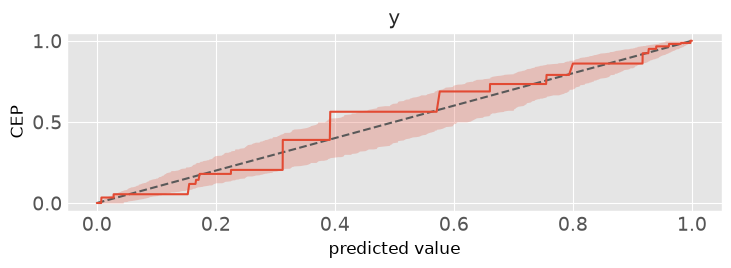

In [4]:
azp.plot_ppc_pava(logistic_fit)

The model probability graph is close to perfect calibration (dashed line). Therefore we can conclude that our Bayesian logistic model fits the data well.

## Bayesian Poisson Regression

Let's repeat the same example with the one we used in GLM notebook again:

**Example**

$n = 200$

$\text{exposure} \sim U(1,5)$

$\text{age} \sim U(20,60)$

True relationship:

$\log(\text{accident}) = -1 + 0.03 \cdot \text{age} + \log(\text{exposure})$

The priors are:

$\beta_0 \sim C(0,5)$

$\beta_1 \sim \text{Flat}$

The likelihood:

$y_i \mid \lambda_i \sim \text{Poisson}(\lambda_i)$

where

$\log(\lambda_i) = \beta_0 + \beta_1\text{age}_i + \log(\text{exposure}_i)$

In [5]:
np.random.seed(42)
n = 200

# Predictors
age = np.random.uniform(20, 60, n)
exposure = np.random.uniform(1, 5, n) 


log_mu = -1 + 0.03 * age + np.log(exposure)
y = np.random.poisson(np.exp(log_mu))

In [6]:
priors = {"Intercept": bmb.Prior("Cauchy", alpha = 0, beta = 5),
          "age": bmb.Prior("Flat")}

dataframe = pd.DataFrame({"y": y, "age": age, "exposure": exposure})

poisson_model = bmb.Model(formula = "y ~ age + offset(np.log(exposure))",
                         data = dataframe,
                         family = "poisson",
                         priors = priors)

poisson_fit = poisson_model.fit(random_seed = 42)
poisson_model.predict(poisson_fit, kind = "response", inplace = True)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [Intercept, age]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 12 seconds.


In [7]:
az.summary(poisson_fit,var_names = ["Intercept","age"], ci_prob = 0.95, ci_kind = "hdi")

,mean,sd,hdi95_lb,hdi95_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,-0.992,0.144,-1.3,-0.72,3159,2338,1.00,0.0026,0.0019
age,0.029,0.00325,0.023,0.036,3296,2561,1.00,5.6e-05,4.1e-05


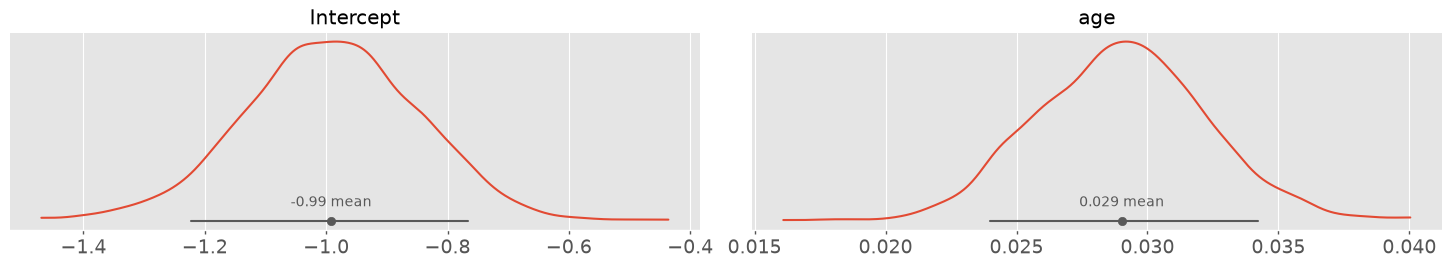

In [8]:
azp.plot_dist(poisson_fit, var_names = ["Intercept","age"],kind = "kde")

Again, we got almost the same results as the frequentist counterpart.

To conclude, we saw how to implement GLMs in the Bayesian framework. Since we used dummy examples, we did not observe any differences between the models. The patterns in the datasets were easy to resolve. So you may wonder why we should use Bayesian statistics in the first place. This is a fair question.

As we saw at the beginning of the Bayesian Statistics series, this implementation is particularly useful when there is reliable knowledge and/or the data are insufficient:

**Use case 1:** If I know from the beginning that the response variable $y$ has many outliers, I can set the likelihood to a Student $t$ distribution, as we did in the previous notebook, and obtain a robust model.

**Use case 2:** An informative prior helps us obtain meaningful prediction intervals even when the dataset is not large enough. To illustrate, if I only have 10 data points about blood sugar levels on infants, I cannot make any meaningful inferences using the frequentist approach. But if I include prior knowledge and opt for Bayesian statistics, I can.

**Use case 3:** By using Bayesian models we can limit the variability of variables individually. For example, blood pressure has physical lower and upper bounds. If the data indicate larger variance, which could be possible in the presence of few data points with a lot of noise, I can incorporate this information into the model from the beginning. In addition to that, a similar logic applies to regularizing the model coefficients. We will cover this topic in the next notebook in more detail.